In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

In [2]:
import os

# Check the dataset is available
base_path = '/kaggle/input'  # Kaggle datasets live here

# Find your dataset folder (update this after you see the output above)
dataset_path = '/kaggle/input/datasets/lukpellant/droneflight-obs-avoidanceairsimrgbdepth10k-320x320/data_collected_potential_final_v58_mod25_320x320_cmds'
print(os.listdir(dataset_path))

['rgb', 'commands', 'depth']


In [3]:
rgb_path = os.path.join(dataset_path, 'rgb')
depth_path = os.path.join(dataset_path, 'depth')
commands_path = os.path.join(dataset_path, 'commands')

RGB: 000000.png
Depth: 000000.npy
Command: 000000.npy
Depth file: /kaggle/input/datasets/lukpellant/droneflight-obs-avoidanceairsimrgbdepth10k-320x320/data_collected_potential_final_v58_mod25_320x320_cmds/depth/000000.npy
Command: [  1.2231183   0.         -0.3599569 -11.846762 ]


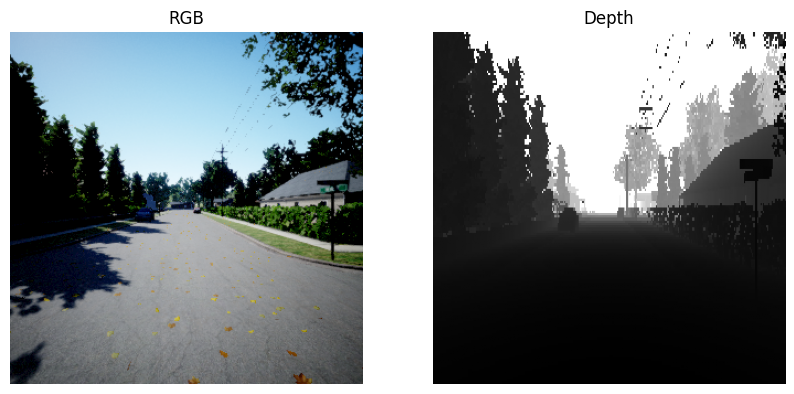

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

idx = 0
# Use SAME index
sample_id = f'{idx:06d}'

rgb_name = f"{sample_id}.png"
depth_name = f"{sample_id}.npy"
command_name = f"{sample_id}.npy"

print("RGB:", rgb_name)
print("Depth:", depth_name)
print("Command:", command_name)

# Full paths
rgb_file = os.path.join(rgb_path, rgb_name)
depth_file = os.path.join(depth_path, depth_name)
command_file = os.path.join(commands_path, command_name)

print("Depth file:", depth_file)


# Load data
rgb_img = Image.open(rgb_file)
depth_array = np.load(depth_file)
command = np.load(command_file)

print("Command:", command)

# Show
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(rgb_img)
ax[0].set_title("RGB")
ax[0].axis('off')

ax[1].imshow(depth_array, cmap='gray')
ax[1].set_title("Depth")
ax[1].axis('off')

plt.show()

In [5]:
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

class DroneDataset(Dataset):
    def __init__(self, dataset_path, dataset_size = 10000):
        self.dataset_path = dataset_path
        self.dataset_size = dataset_size

        # rgb normalization function
        self.rgb_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),  # random lighting changes
            transforms.RandomHorizontalFlip(p=0.3),                # flip sometimes
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
        

        # depth normalization
        self.depth_transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        sample_id = f'{idx:06d}'
        # Load RGB
        rgb = Image.open(f'{self.dataset_path}/rgb/{sample_id}.png').convert('RGB')
        rgb = self.rgb_transform(rgb)

        # Load Depth
        depth = np.load(f'{self.dataset_path}/depth/{sample_id}.npy')
        depth = depth.squeeze()                   # make sure it's 2D (H, W)
        depth = Image.fromarray(depth.astype(np.float32))  # convert to PIL for transform
        depth = self.depth_transform(depth)       # shape: (1, 224, 224)

        # Load Command
        command = np.load(f'{self.dataset_path}/commands/{sample_id}.npy')
        command = torch.tensor(command, dtype=torch.float32)  # shape: (4,)
        
        return rgb, depth, command

In [6]:
full_dataset = DroneDataset(dataset_path, 10000)

# Split: 80% train, 10% val, 10% test
train_size = 8000
val_size   = 1000
test_size  = 1000

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

Train: 8000 | Val: 1000 | Test: 1000


In [7]:
import torchvision.models as models
class DroneModel(nn.Module):
    def __init__(self):
        super(DroneModel, self).__init__()
        resnet = models.resnet18(weights='IMAGENET1K_V1')

        # freezing resnet layers to avoid overfitting
        for param in resnet.parameters():
            param.requires_grad = False
        # Unfreeze only the last block
        for param in resnet.layer4.parameters():
            param.requires_grad = True

        # RGB branch resnet with the last classification layer removed
        self.rgb_branch = nn.Sequential(*list(resnet.children())[:-1])

        # Depth branch 
        self.depth_branch = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 112x112
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # output: (batch, 128, 1, 1)
        )

        self.head_main = nn.Sequential(
            nn.Linear(640, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 3)   # vx, vy, vz
        )

        self.head_yaw = nn.Sequential(
            nn.Linear(640, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 1)   # yaw_rate only
        )
    def forward(self, rgb, depth):
        rgb_feat = self.rgb_branch(rgb).flatten(1)
        depth_feat = self.depth_branch(depth).flatten(1)

        combined = torch.cat([rgb_feat, depth_feat], dim=1)
        main_out = self.head_main(combined)
        yaw_out = self.head_yaw(combined)
        return torch.cat([main_out, yaw_out], dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = DroneModel().to(device)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


In [8]:
def weighted_mse(preds, targets):
    weights = torch.tensor([1.0, 1.0, 1.0, 0.05], device=preds.device)
    return ((preds - targets) ** 2 * weights).mean()

In [9]:
def criterion(preds, targets):
    weights = torch.tensor([1.0, 1.0, 1.0, 0.05], device=preds.device)
    return ((preds - targets) ** 2 * weights).mean()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


EPOCHS = 25
best_val_loss = float('inf')

patience = 5
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    print(f"Going through epoch number: {epoch + 1}")
    # training
    model.train()
    train_loss = 0
    for rgb, depth, command in train_loader:
        rgb, depth, command = rgb.to(device), depth.to(device), command.to(device)
        optimizer.zero_grad()
        preds = model(rgb, depth)
        loss = criterion(preds, command)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_loss /= len(train_loader)
    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        
        for rgb, depth, command in val_loader:
            rgb, depth, command = rgb.to(device), depth.to(device), command.to(device)
            preds = model(rgb, depth)
            loss = criterion(preds, command)
            val_loss += loss.item()
        val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),"best_model.pth")
        patience_counter = 0
    else:
        patience_counter+=1
        if patience_counter >= patience:
            print(f"Early stopping at epoch: {epoch + 1}")
            break
    
            

Going through epoch number: 1
Epoch 1/25 | Train Loss: 5.5472 | Val Loss: 4.8128
Going through epoch number: 2
Epoch 2/25 | Train Loss: 3.9392 | Val Loss: 2.6797
Going through epoch number: 3
Epoch 3/25 | Train Loss: 2.2159 | Val Loss: 2.9315
Going through epoch number: 4


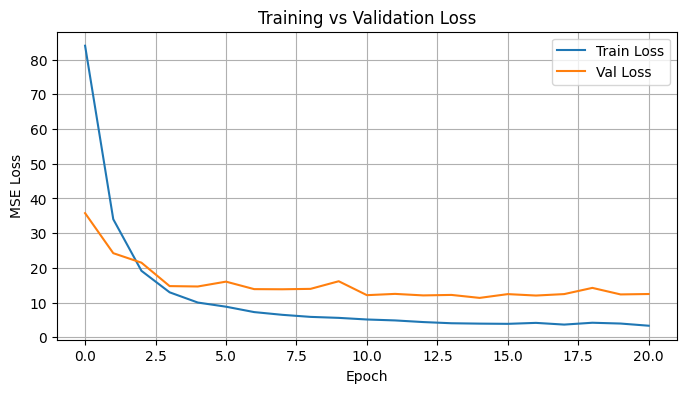

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for rgb, depth, command in test_loader:
        rgb, depth = rgb.to(device), depth.to(device)
        preds = model(rgb, depth)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(command.numpy())

all_preds   = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

mae = np.mean(np.abs(all_preds - all_targets), axis=0)
print(f'MAE per command:')
print(f'  vx:       {mae[0]:.4f}')
print(f'  vy:       {mae[1]:.4f}')
print(f'  vz:       {mae[2]:.4f}')
print(f'  yaw_rate: {mae[3]:.4f}')
print(f'  Overall MAE: {mae.mean():.4f}')

MAE per command:
  vx:       0.4736
  vy:       0.0251
  vz:       0.2471
  yaw_rate: 3.9732
  Overall MAE: 1.1797


In [12]:
import numpy as np

np.save('all_preds.npy', all_preds)
np.save('all_targets.npy', all_targets)

import pandas as pd
df = pd.DataFrame(
    np.hstack([all_targets, all_preds]),
    columns=['true_vx','true_vy','true_vz','true_yaw',
             'pred_vx','pred_vy','pred_vz','pred_yaw']
)
df.to_csv('predictions.csv', index=False)

In [13]:
import json

metrics = {
    'mae_vx':       float(mae[0]),
    'mae_vy':       float(mae[1]),
    'mae_vz':       float(mae[2]),
    'mae_yaw_rate': float(mae[3]),
    'overall_mae':  float(mae.mean())
}
with open('results.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("Results saved to results.json")

Results saved to results.json


In [14]:
plt.savefig('predictions_plot.png', dpi=150)

<Figure size 640x480 with 0 Axes>